In [1]:
# ==============================================================================
# STEP 0: INSTALL & IMPORT DEPENDENCIES
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

In [2]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("--- 1. LOADING DATASET ---")
# Ensure 'transactions.csv' is uploaded to your Google Colab files section
file_path = 'transactions.csv'
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

--- 1. LOADING DATASET ---
Dataset Shape: 299695 rows, 17 columns


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [3]:
# ==============================================================================
# STEP 2: DATA PREPROCESSING (IN DETAIL)
# ==============================================================================
print("\n--- 2. DATA PREPROCESSING ---")

df_processed = df.copy()

# A. Drop non-predictive identifiers
drop_cols = ['transaction_id', 'user_id']
df_processed = df_processed.drop(columns=drop_cols)
print(f"-> Dropped ID columns: {drop_cols}")

# B. Extract datetime features
df_processed['transaction_time'] = pd.to_datetime(df_processed['transaction_time'])
df_processed['hour'] = df_processed['transaction_time'].dt.hour
df_processed['dayofweek'] = df_processed['transaction_time'].dt.dayofweek
df_processed['month'] = df_processed['transaction_time'].dt.month
df_processed = df_processed.drop(columns=['transaction_time'])
print("-> Extracted temporal features: 'hour', 'dayofweek', 'month'")

# C. Categorical Encoding (Label Encoding)
cat_cols = ['country', 'bin_country', 'channel', 'merchant_category']
encoder = LabelEncoder()

for col in cat_cols:
    df_processed[col] = encoder.fit_transform(df_processed[col].astype(str))
print(f"-> Encoded categorical columns: {cat_cols}")

# D. Check Missing Values & Target Imbalance
missing = df_processed.isnull().sum().sum()
print(f"-> Total Missing Values: {missing}")

target_counts = df_processed['is_fraud'].value_counts(normalize=True) * 100
print(f"-> Target Class Distribution ('is_fraud'):\n   0 (Non-Fraud): {target_counts[0]:.2f}%\n   1 (Fraud): {target_counts[1]:.2f}%")


--- 2. DATA PREPROCESSING ---
-> Dropped ID columns: ['transaction_id', 'user_id']
-> Extracted temporal features: 'hour', 'dayofweek', 'month'
-> Encoded categorical columns: ['country', 'bin_country', 'channel', 'merchant_category']
-> Total Missing Values: 0
-> Target Class Distribution ('is_fraud'):
   0 (Non-Fraud): 97.79%
   1 (Fraud): 2.21%


In [4]:
# ==============================================================================
# STEP 3: DATA SPLIT & FEATURE SCALING
# ==============================================================================
print("\n--- 3. DATA SPLITTING & SCALING ---")

X = df_processed.drop(columns=['is_fraud'])
y = df_processed['is_fraud']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling for models that benefit from normalized data
scaler = StandardScaler()
num_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'shipping_distance_km']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set dimensions: {X_train.shape}")
print(f"Testing set dimensions:  {X_test.shape}")


--- 3. DATA SPLITTING & SCALING ---
Training set dimensions: (239756, 16)
Testing set dimensions:  (59939, 16)


In [5]:
# ==============================================================================
# STEP 4: MODEL IMPLEMENTATION
# ==============================================================================
print("\n--- 4. MODEL IMPLEMENTATION & TRAINING ---")

# 1. Decision Tree Classifier
print("Training Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Linear Regression (Adapted for binary classification via 0.5 thresholding)
print("Training Linear Regression (with classification thresholding)...")
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# 3. XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions and Probabilities
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Linear Regression Continuous Output -> Thresholded to Binary
y_prob_lin = lin_reg_model.predict(X_test)
y_prob_lin_clipped = np.clip(y_prob_lin, 0, 1) # Keep within [0, 1] range for ROC
y_pred_lin = (y_prob_lin_clipped >= 0.5).astype(int)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


--- 4. MODEL IMPLEMENTATION & TRAINING ---
Training Decision Tree Classifier...
Training Linear Regression (with classification thresholding)...
Training XGBoost Classifier...


In [6]:
# ==============================================================================
# STEP 5: MODEL EVALUATION & RANK TABLE
# ==============================================================================
print("\n--- 5. MODEL EVALUATION & RANK TABLE ---")

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = [
    evaluate_model('Decision Tree', y_test, y_pred_dt),
    evaluate_model('Linear Regression', y_test, y_pred_lin),
    evaluate_model('XGBoost', y_test, y_pred_xgb)
]

# Create Rank Table sorted by F1-Score
rank_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = 'Rank'

print("\n=================== MODEL RANK TABLE ===================")
display(rank_df.style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'}))

# Detailed Classification Reports
print("\n--- Classification Report: Decision Tree ---")
print(classification_report(y_test, y_pred_dt, target_names=['Non-Fraud', 'Fraud']))

print("\n--- Classification Report: Linear Regression ---")
print(classification_report(y_test, y_pred_lin, target_names=['Non-Fraud', 'Fraud']))

print("\n--- Classification Report: XGBoost ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Fraud', 'Fraud']))


--- 5. MODEL EVALUATION & RANK TABLE ---

=================== MODEL RANK TABLE ===================


,Model,Accuracy,Precision,Recall,F1-Score
Rank,,,,,
1,XGBoost,0.9925,0.9163,0.7284,0.8116
2,Decision Tree,0.9921,0.9205,0.7005,0.7955
3,Linear Regression,0.9802,0.9136,0.1120,0.1995



--- Classification Report: Decision Tree ---
              precision    recall  f1-score   support

   Non-Fraud       0.99      1.00      1.00     58617
       Fraud       0.92      0.70      0.80      1322

    accuracy                           0.99     59939
   macro avg       0.96      0.85      0.90     59939
weighted avg       0.99      0.99      0.99     59939


--- Classification Report: Linear Regression ---
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.99     58617
       Fraud       0.91      0.11      0.20      1322

    accuracy                           0.98     59939
   macro avg       0.95      0.56      0.59     59939
weighted avg       0.98      0.98      0.97     59939


--- Classification Report: XGBoost ---
              precision    recall  f1-score   support

   Non-Fraud       0.99      1.00      1.00     58617
       Fraud       0.92      0.73      0.81      1322

    accuracy                           0.99   


--- 6. GENERATING VISUALIZATIONS ---


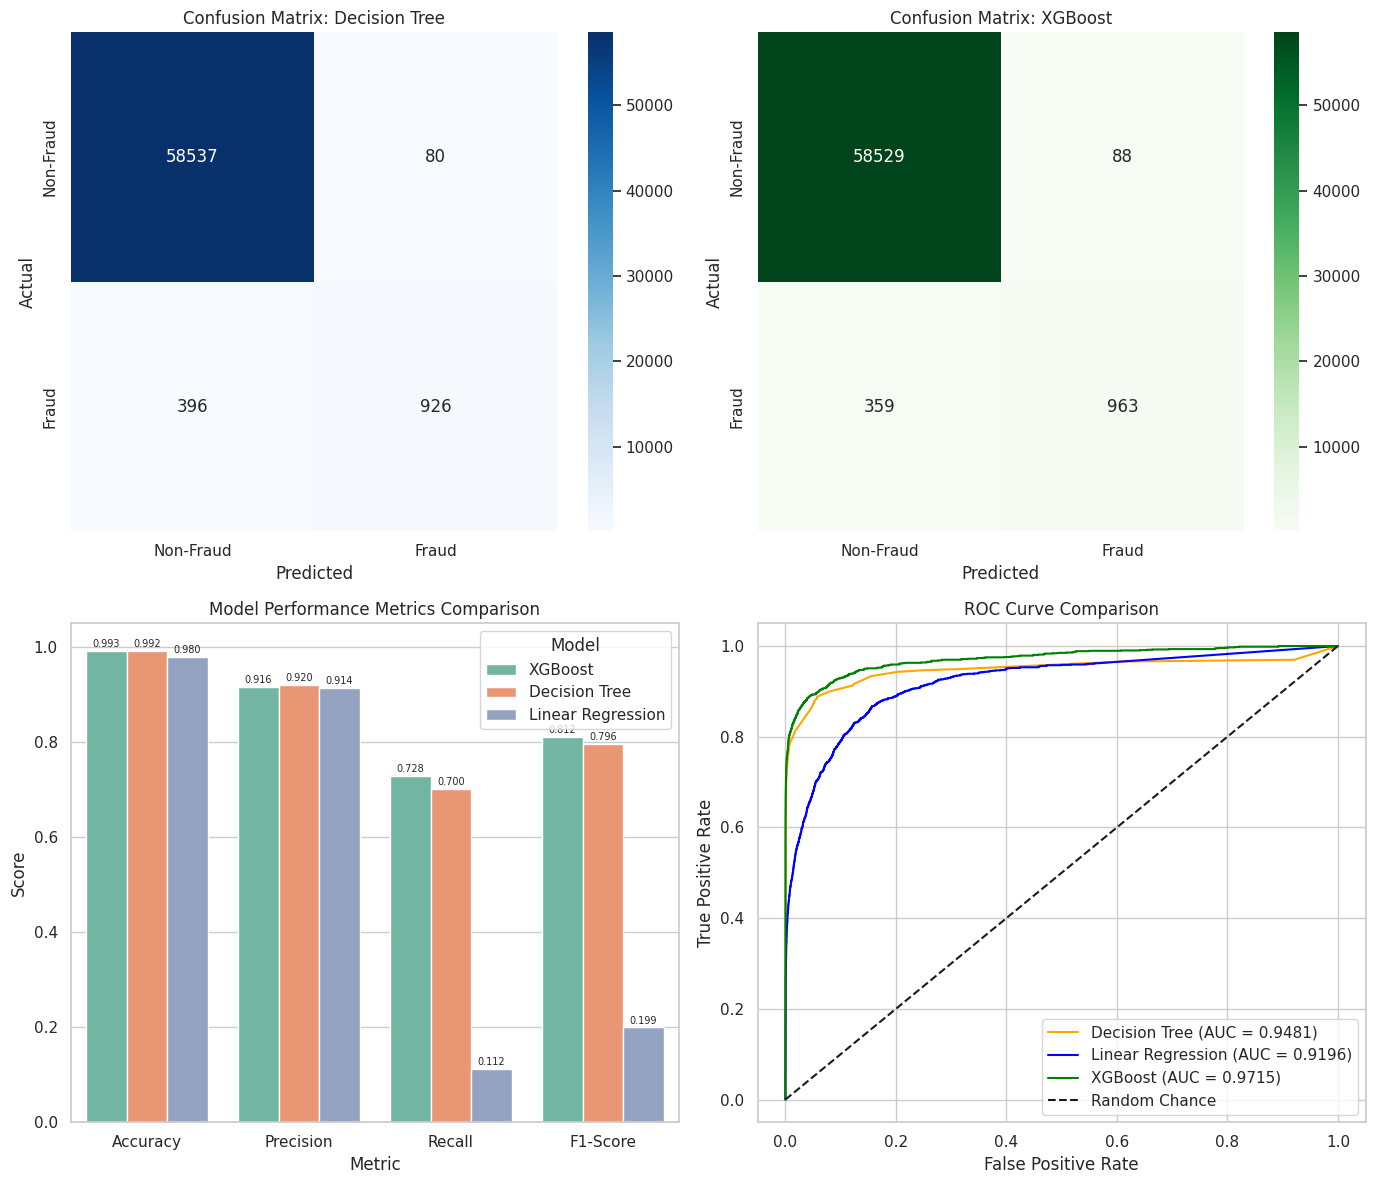

/tmp/ipykernel_1818/2781137718.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='magma')


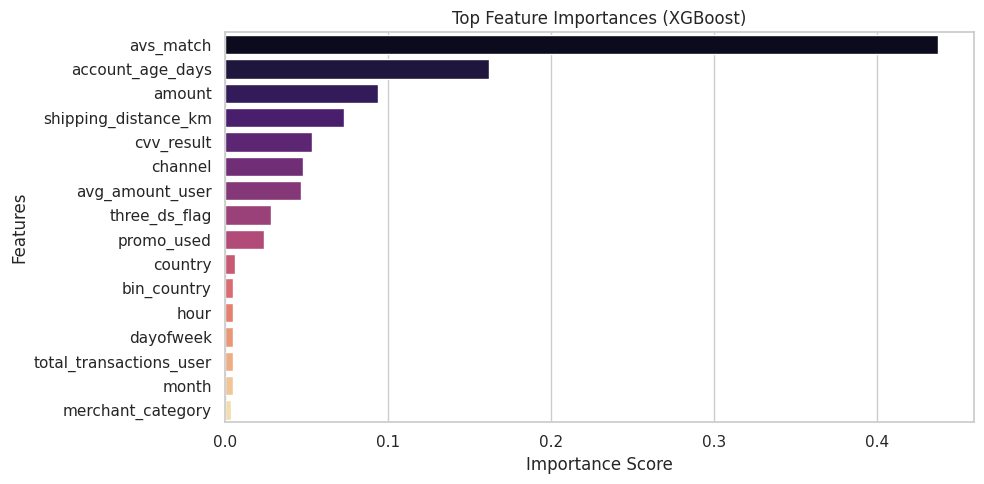

In [7]:
# ==============================================================================
# STEP 6: VISUALIZATIONS
# ==============================================================================
print("\n--- 6. GENERATING VISUALIZATIONS ---")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Confusion Matrix - Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[0, 0].set_title('Confusion Matrix: Decision Tree')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Plot 2: Confusion Matrix - XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[0, 1].set_title('Confusion Matrix: XGBoost')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Plot 3: Metrics Comparison Bar Chart
metrics_melted = rank_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                              var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Model Performance Metrics Comparison')
axes[1, 0].set_ylim(0.0, 1.05)
for p in axes[1, 0].patches:
    if p.get_height() > 0:
        axes[1, 0].annotate(f"{p.get_height():.3f}",
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', xytext=(0, 5),
                            textcoords='offset points', fontsize=7)

# Plot 4: ROC Curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_lin, tpr_lin, _ = roc_curve(y_test, y_prob_lin_clipped)
auc_lin = auc(fpr_lin, tpr_lin)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

axes[1, 1].plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', color='orange')
axes[1, 1].plot(fpr_lin, tpr_lin, label=f'Linear Regression (AUC = {auc_lin:.4f})', color='blue')
axes[1, 1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', color='green')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random Chance')
axes[1, 1].set_title('ROC Curve Comparison')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Plot 5: Feature Importances (XGBoost)
plt.figure(figsize=(10, 5))
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='magma')
plt.title('Top Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()